In [2]:
# EDA for WikiEdits-MultiGEC English Subset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from difflib import SequenceMatcher

# Load data
df = pd.read_csv("../data/raw/wikiedits_english.csv")

print(f"Total examples: {len(df)}")
df.head()

Total examples: 10000


,original_text,corrected_text,language,url
0,"In March 2019, men in plain clothes, claiming ...","In March 2019, men in plain clothes, claiming ...",english,NaN
1,Richard W. Hughes is an American gemologist an...,Richard W. Hughes is an American gemologist an...,english,NaN
2,Hughes has authored or co-authored a number of...,Hughes has authored or co-authored a number of...,english,NaN
3,Lakshya came into the world on 28 March 1990 i...,Lakshya was born on 28 March 1990 in Jalandhar...,english,NaN
4,"Ten Thousand Villages is a nonprofit, fair tra...","Ten Thousand Villages is a nonprofit, fair tra...",english,NaN


Sentence length stats:
       original_len  corrected_len      len_diff
count  10000.000000   10000.000000  10000.000000
mean      66.396500      65.078500     -1.318000
std       43.490765      43.280031     11.720052
min        3.000000       1.000000   -192.000000
25%       37.000000      36.000000     -1.000000
50%       56.000000      55.000000      0.000000
75%       84.000000      82.000000      1.000000
max      509.000000     510.000000    317.000000


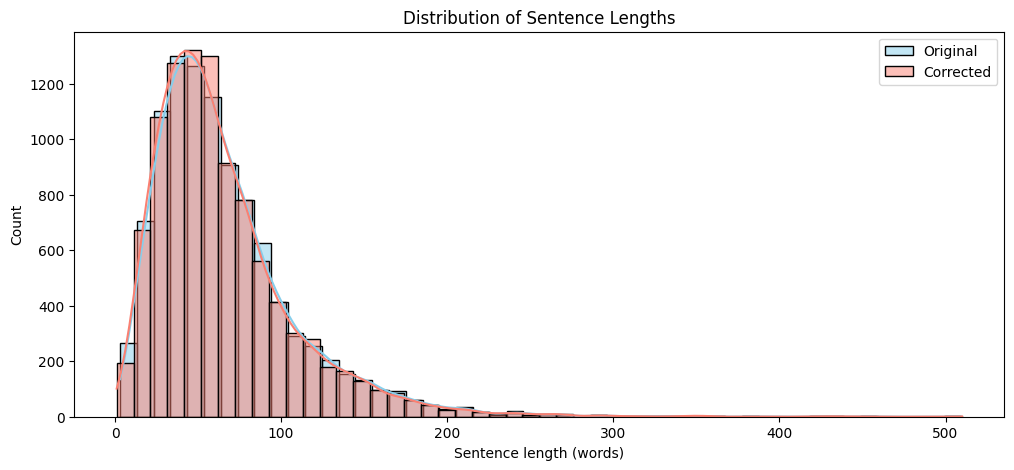

In [3]:

# -----------------------------
# Sentence length analysis
# -----------------------------
df['original_len'] = df['original_text'].apply(lambda x: len(str(x).split()))
df['corrected_len'] = df['corrected_text'].apply(lambda x: len(str(x).split()))
df['len_diff'] = df['corrected_len'] - df['original_len']

print("Sentence length stats:")
print(df[['original_len','corrected_len','len_diff']].describe())

# Plot sentence length distributions
plt.figure(figsize=(12,5))
sns.histplot(df['original_len'], color='skyblue', label='Original', kde=True, bins=50)
sns.histplot(df['corrected_len'], color='salmon', label='Corrected', kde=True, bins=50)
plt.xlabel("Sentence length (words)")
plt.ylabel("Count")
plt.title("Distribution of Sentence Lengths")
plt.legend()
plt.show()


Diff ratio stats:
count    10000.000000
mean         0.093622
std          0.163561
min          0.000161
25%          0.005102
50%          0.022971
75%          0.095174
max          0.992218
Name: diff_ratio, dtype: float64


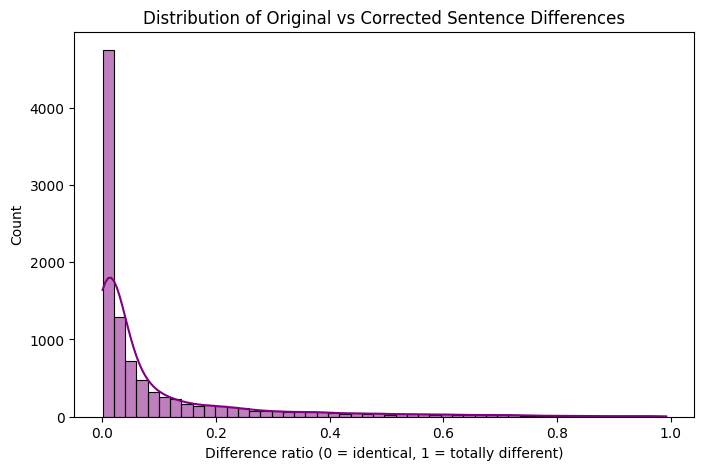

In [4]:

# -----------------------------
# Compute basic difference ratio (rough measure of error)
# -----------------------------
def diff_ratio(a, b):
    return 1 - SequenceMatcher(None, a, b).ratio()

df['diff_ratio'] = df.apply(lambda x: diff_ratio(str(x['original_text']), str(x['corrected_text'])), axis=1)

print("Diff ratio stats:")
print(df['diff_ratio'].describe())

# Plot histogram of diff ratios
plt.figure(figsize=(8,5))
sns.histplot(df['diff_ratio'], bins=50, kde=True, color='purple')
plt.xlabel("Difference ratio (0 = identical, 1 = totally different)")
plt.ylabel("Count")
plt.title("Distribution of Original vs Corrected Sentence Differences")
plt.show()


In [5]:

# -----------------------------
# Quick sample inspection
# -----------------------------
print("Random examples with changes:")
for i, row in df.sample(5, random_state=42).iterrows():
    print(f"\nOriginal:  {row['original_text']}")
    print(f"Corrected: {row['corrected_text']}")
    print(f"Words diff: {row['len_diff']}, Diff ratio: {row['diff_ratio']:.2f}")


Random examples with changes:

Original:  On the 7th of December, Kandi's chairman released a response addressing Hindenburg's short seller report. Kandi replied to the report with a statement claiming, "Kandi believes that the report contains numerous errors, misstatements of historical facts, inaccurate conclusions, and superfluous opinions."
Corrected: On the 7th of December, Kandi's chairman released a response addressing Hindenburg's short seller report. Kandi responded to the report with a statement claiming that, "Kandi believes that the report contains numerous errors, misstatements of historical facts, inaccurate conclusions, and superfluous opinions."
Words diff: 1, Diff ratio: 0.02

Original:  Schaefer’s films have screened at festivals such as the Berlin International Film Festival and South by Southwest (SXSW). His work has been made available on platforms including Netflix, Amazon Prime, Hulu, HBO, PBS, and the Sundance Channel.
Corrected: Schaefer’s films have screened a

In [6]:

# -----------------------------
# Optional: filter high-diff sentences (likely more complex errors)
# -----------------------------
high_diff = df[df['diff_ratio'] > 0.3]
print(f"\nSentences with diff_ratio > 0.3: {len(high_diff)}")
high_diff.sample(5, random_state=42)



Sentences with diff_ratio > 0.3: 974


,original_text,corrected_text,language,url,original_len,corrected_len,len_diff,diff_ratio
1937,Armstrong's Point is one of Winnipeg's most af...,Armstrong's Point is one of Winnipeg's most af...,english,NaN,33,33,0,0.318284
6006,The Nokken Hotel Cabins are primarily construc...,The Nokken Hotel Cabins are primarily construc...,english,NaN,46,42,-4,0.523649
1656,"Bhupal Rai (, born December 29, 1960) is a Nep...","Bhupal Rai (, born December 29, 1960) is a Nep...",english,NaN,48,50,2,0.579618
5317,"In 1996, the idea of establishing a university...","In 1996, the idea of establishing a university...",english,NaN,73,34,-39,0.357860
593,Helmbrecht ran for U.S. House of Representativ...,Helmbrecht ran for U.S. House of Representativ...,english,NaN,41,39,-2,0.304015
